# Question 1: Data Preprocessing



**Case Study: Analyzing Student Academic Performance**

Eduvos is a private higher education institution offering a range of undergraduate and postgraduate qualifications within its Information Technology (IT) Faculty. As part of its ongoing commitment to academic quality and student success, Eduvos routinely evaluates student performance and the effectiveness of academic support initiatives.

For the current academic cycle, Eduvos has commissioned your analytics team to examine student performance within the IT Faculty at a granular level. The institution is particularly interested in understanding overall academic outcomes, student progression patterns, and the role that tutorial classes play in supporting learning and improving pass rates.

You have been provided with an anonymised dataset named **“student_performance.csv”** in the “Project Datasets” folder on myLMS containing detailed academic and tutorial attendance information for students registered in the IT Faculty during a given academic year. In the folder is a document providing a detailed description of the dataset variables.

The outcomes of this project will inform senior academic management and contribute to strategic planning aimed at improving student success within the IT Faculty.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1.1. You will notice that there are spelling errors and inconsistencies in the ***qualification*** and ***passed_all_modules*** columns. **Standardize** the values in these columns to improve the data consistency.

In [ ]:
data = pd.read_csv("student_performance.csv", index_col=0)

In [ ]:
data.head(5)

,academic_year,gender,qualification,study_level,modules,module_credits,grade_average,modules_passed,pass_rate,passed_all_modules,tutorial_classes_attended,tutorial_class_modules
0,2024,Male,BSc IT: Data Science,1st year,8,94,41.0,3,37.5,No,5.0,2.0
1,2024,Male,Higher Certificate in Information Systems: Sof...,3rd year,7,106,55.0,5,71.4,No,19.0,2.0
2,2024,Male,BSc IT: Data Science,3rd year,1,16,53.0,1,100.0,Yes,0.0,0.0
3,2024,Female,BSc IT: Data Science,3rd year,4,72,72.0,4,100.0,Yes,0.0,0.0
4,2024,Female,Higher Certificate in Information Systems: Sof...,2nd year,11,156,64.0,11,100.0,Yes,62.0,11.0


In [ ]:
data["qualification"].unique()

array(['BSc IT: Data Science',
       'Higher Certificate in Information Systems: Software Development',
       'BSc in CompUter Science', 'BSc IT: Software Engineering',
       'Higher Certificate in Information Systems: Cloud Computing',
       'Higher Certificate in Information Systems: Cyber Security',
       'BSc IT: Robotics', 'BSc IT: Security and Network Engineering',
       'BSC IT: ROBOTICS'], dtype=object)

Standerdizing Qualification column

In [ ]:
data["qualification"] = data["qualification"].str.strip()
data["qualification"] = data["qualification"].replace({
   "BSc in CompUter Science": "BSc in Computer Science",
   "BSC IT: ROBOTICS" : "BSc IT: Robotics"
})

In [ ]:
data["qualification"].unique()

array(['BSc IT: Data Science',
       'Higher Certificate in Information Systems: Software Development',
       'BSc in Computer Science', 'BSc IT: Software Engineering',
       'Higher Certificate in Information Systems: Cloud Computing',
       'Higher Certificate in Information Systems: Cyber Security',
       'BSc IT: Robotics', 'BSc IT: Security and Network Engineering'],
      dtype=object)

Standerdizing passed_all_modules

In [ ]:
data["passed_all_modules"].unique()

array(['No', 'NOPE', 'YES', 'YEAH', 'Yes', 'no', 'yes'], dtype=object)

In [ ]:
data["passed_all_modules"] = data["passed_all_modules"].replace({
   "yes" : "Yes",
   "no" : "No",
   "NOPE" : "No",
   "YEAH" : "Yes",
   "no" : "No",
   "YES" : "Yes"
})

In [ ]:
data["passed_all_modules"].unique()

array(['No', 'Yes'], dtype=object)

1.2. Replace the **missing values** in the '***tutorial_classes_attended***' and '***tutorial_class_modules***’ columns with a **zero**.

In [ ]:
data.isna().sum()

,0
academic_year,0
gender,0
qualification,0
study_level,0
modules,0
module_credits,0
grade_average,3
modules_passed,0
pass_rate,0
passed_all_modules,0


In [ ]:
data["tutorial_classes_attended"] = data["tutorial_classes_attended"].fillna(0)
data["tutorial_class_modules"] = data["tutorial_class_modules"].fillna(0)
data.isna().sum()

,0
academic_year,0
gender,0
qualification,0
study_level,0
modules,0
module_credits,0
grade_average,3
modules_passed,0
pass_rate,0
passed_all_modules,0


1.3. Handle any remaining **missing values** in the data by performing the appropriate missing value treatment.

In [ ]:
data['grade_average'] = data.groupby('qualification')['grade_average'] \
                          .transform(lambda x: x.fillna(x.median()))
data['grade_average'] = data['grade_average'].fillna(data['grade_average'].median())
data.isna().sum()

,0
academic_year,0
gender,0
qualification,0
study_level,0
modules,0
module_credits,0
grade_average,0
modules_passed,0
pass_rate,0
passed_all_modules,0


# Question 2: Exploratory Data Analysis

2.1 Use visualizations and descriptive statistics to explore the dataset and answer the following questions. Focus on clarity, relevance, and insightful analysis in your visualizations and interpretations.

**1. Academic Performance by Qualification**

a)    Which qualifications have the highest average pass rates, and how do they compare across the IT Faculty?

In [ ]:
qualification_pass = (
    data.groupby('qualification')['pass_rate']
    .agg(
        avg_pass_rate='mean',
        median_pass_rate='median',
        num_students='count'
    )
    .sort_values('avg_pass_rate', ascending=False)
    .round(1)
)
qualification_pass

,avg_pass_rate,median_pass_rate,num_students
qualification,,,
Higher Certificate in Information Systems: Cyber Security,90.0,100.0,94
Higher Certificate in Information Systems: Software Development,85.4,100.0,669
Higher Certificate in Information Systems: Cloud Computing,83.0,90.3,140
BSc IT: Data Science,78.0,90.0,179
BSc IT: Robotics,78.0,87.5,30
BSc in Computer Science,76.6,91.7,197
BSc IT: Software Engineering,72.9,87.1,28
BSc IT: Security and Network Engineering,56.9,64.3,11


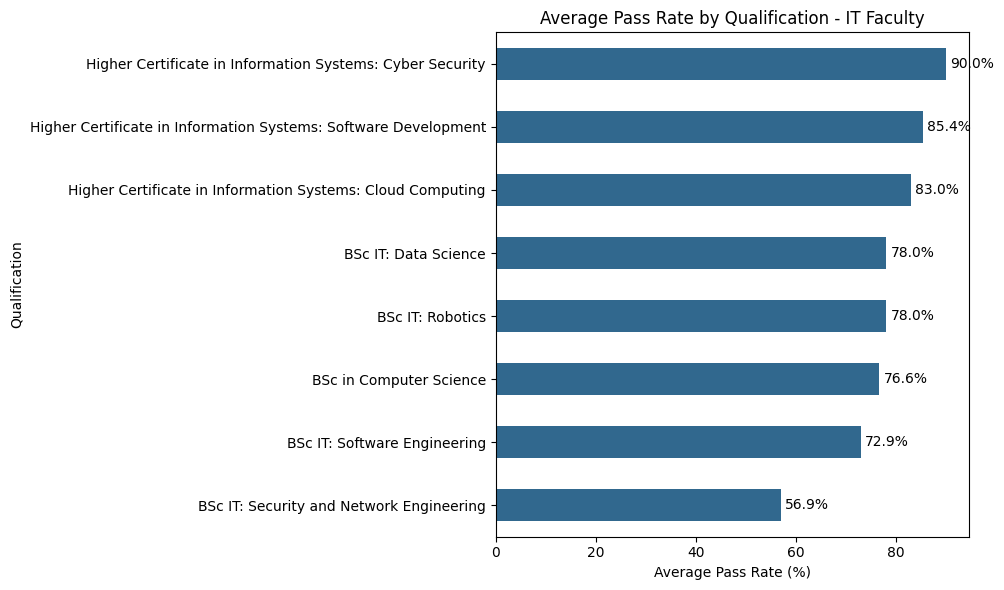

In [ ]:
# Lets visualize the pass rate
ax = qualification_pass['avg_pass_rate'].plot.barh(figsize=(10, 6), color='#31688e')
ax.invert_yaxis()
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.set(
    xlabel='Average Pass Rate (%)',
    ylabel='Qualification',
    title='Average Pass Rate by Qualification - IT Faculty'
)

plt.tight_layout()
plt.show()

b)    How does the distribution of pass rates vary within each qualification (distributional differences)?
Use an appropriate visualization to compare spread, central tendency, and potential outliers across qualifications.

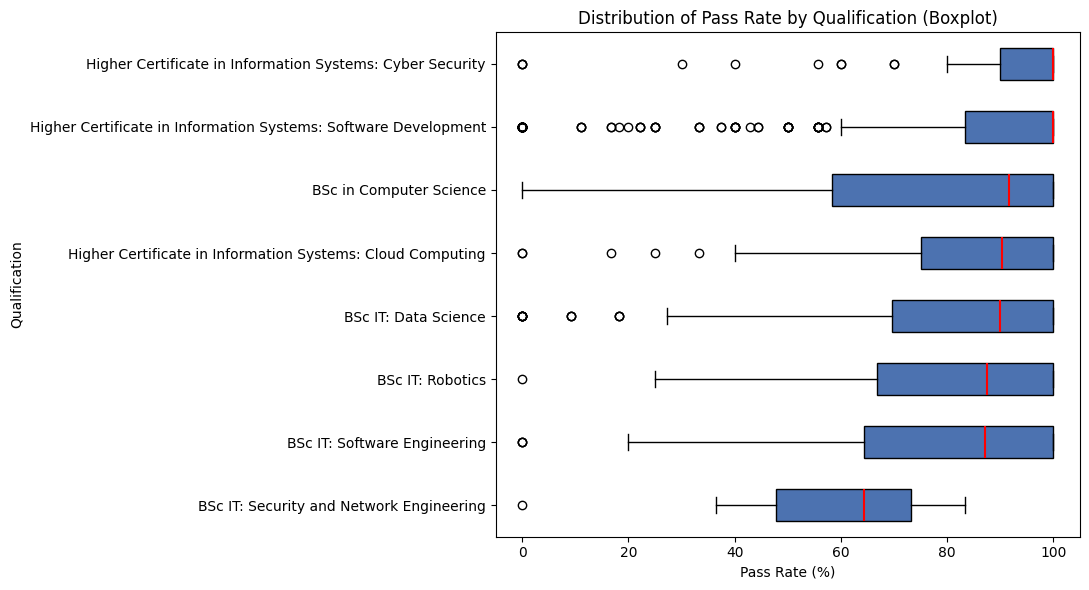

In [ ]:
ordered_qualifications = (
    data.groupby('qualification')['pass_rate']
    .median()
    .sort_values(ascending=False)
    .index
)
data_to_plot = [data[data['qualification'] == q]['pass_rate'] for q in ordered_qualifications]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(
    data_to_plot,
    tick_labels=ordered_qualifications,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#4C72B0', color='black'),
    medianprops=dict(color='red', linewidth=1.5)
)

ax.invert_yaxis()
ax.set(
    xlabel='Pass Rate (%)',
    ylabel='Qualification',
    title='Distribution of Pass Rate by Qualification (Boxplot)'
)

plt.tight_layout()
plt.show()

**2. Tutoring and Student Success**

a)    At an overall faculty level, how does tutorial attendance relate to passing all modules? Compare the percentage who passed all modules for students who attended tutorials vs those who did not.

In [ ]:
data['attended_tutorials'] = np.where(
    data['tutorial_classes_attended'] > 0,
    'Attended Tutorials',
    'No Tutorials'
)

overall_tab = (pd.crosstab(data['attended_tutorials'], data['passed_all_modules'], normalize='index')
    .mul(100)
    .round(1)
)

overall_tab

passed_all_modules,No,Yes
attended_tutorials,,
Attended Tutorials,49.9,50.1
No Tutorials,36.2,63.8


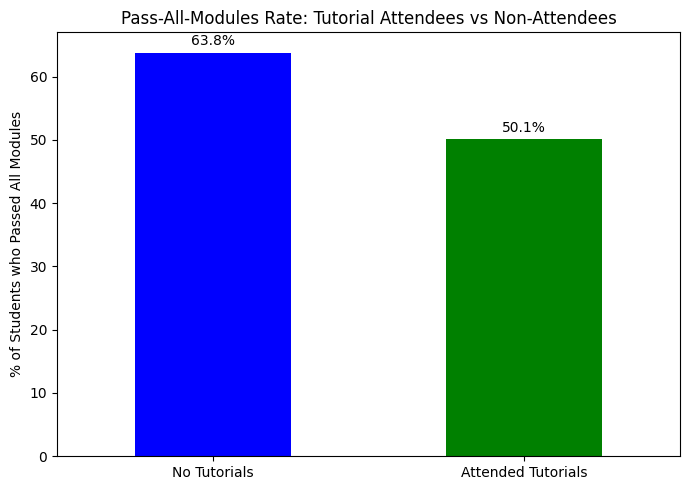

In [ ]:
plot_data = overall_tab['Yes'].sort_values(ascending=False)
ax = plot_data.plot(
    kind='bar',
    figsize=(7, 5),
    color=['blue','green'],
    rot=0
)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.set(
    ylabel='% of Students who Passed All Modules',
    xlabel='',
    title='Pass-All-Modules Rate: Tutorial Attendees vs Non-Attendees'
)

plt.tight_layout()
plt.show()

b)    Within each qualification, does tutorial attendance appear to be associated with improved outcomes (passing all modules)?

In [ ]:
qualification_tut = data.groupby(['qualification','attended_tutorials'])['passed_all_modules'] \
.apply(lambda x: (x=='Yes').mean()*100).unstack()
qualification_tut = qualification_tut.round(1)
qualification_tut


attended_tutorials,Attended Tutorials,No Tutorials
qualification,,
BSc IT: Data Science,32.2,76.7
BSc IT: Robotics,33.3,44.4
BSc IT: Security and Network Engineering,0.0,0.0
BSc IT: Software Engineering,19.0,71.4
BSc in Computer Science,38.3,65.7
Higher Certificate in Information Systems: Cloud Computing,39.1,70.0
Higher Certificate in Information Systems: Cyber Security,0.0,60.2
Higher Certificate in Information Systems: Software Development,61.6,58.3


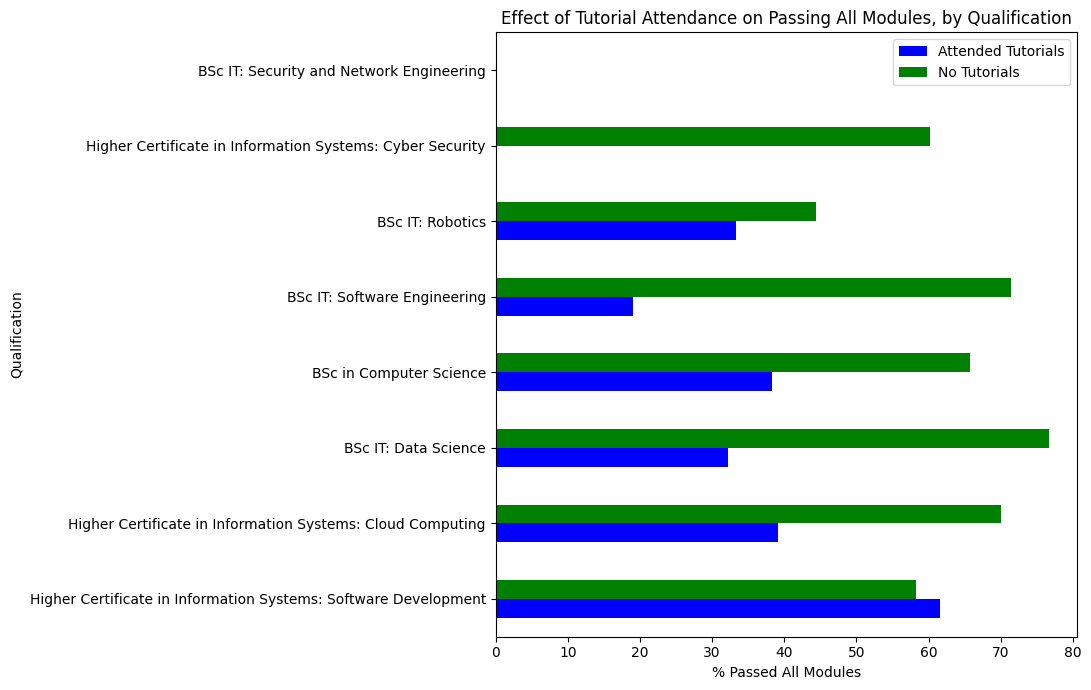

In [ ]:
fig, ax = plt.subplots(figsize=(11,7))
qualification_tut.loc[qualification_tut.mean(axis=1).sort_values(ascending=False).index].plot(
kind='barh', ax=ax, color=['blue','green'])
ax.set_xlabel('% Passed All Modules')
ax.set_ylabel('Qualification')
ax.set_title('Effect of Tutorial Attendance on Passing All Modules, by Qualification')
ax.legend(title='')
plt.tight_layout()
plt.show()

c)  How does average tutorial attendance differ across study levels?

In [ ]:
level_order = ['1st year', '2nd year', '3rd year']
level_tut = (
    data.groupby('study_level')['tutorial_classes_attended']
    .agg(
        avg_classes_attended='mean',
        median_classes_attended='median',
        n_students='count'
    )
    .reindex(level_order).round(1)
)

level_tut

,avg_classes_attended,median_classes_attended,n_students
study_level,,,
1st year,30.2,25.0,737
2nd year,29.2,25.0,328
3rd year,7.4,3.0,283


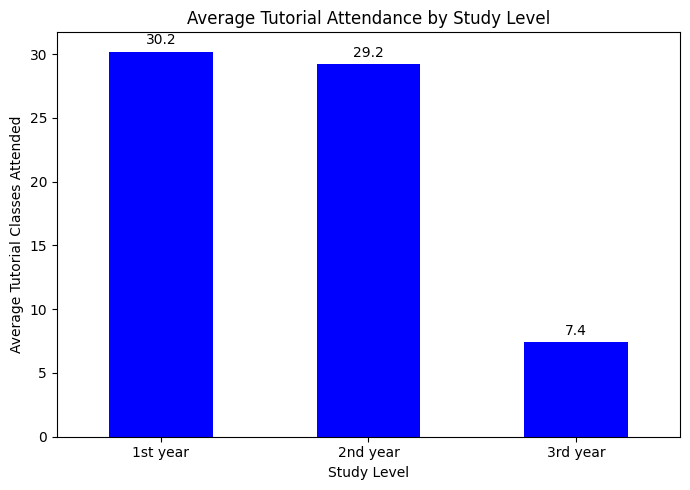

In [ ]:
ax = level_tut['avg_classes_attended'].plot(kind='bar', figsize=(7, 5),color='blue', rot=0)

ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
ax.set(
    xlabel='Study Level',
    ylabel='Average Tutorial Classes Attended',
    title='Average Tutorial Attendance by Study Level'
)
plt.tight_layout()
plt.show()

2.2. Based on your above analysis, provide a short report detailing your findings / insights derived from the data that may be useful to Eduvos to better understand student performance and academic support within the IT Faculty. Additionally, provide recommendations to improve or maintain current student performance. Ensure that your findings are relevant based on your analysis and visualizations, and that they are articulated well. Your recommendations should be innovative, detailed and actionable.

**My Key Findings**

* Performance is not uniform across the Faculty: BSc IT: Security and Network Engineering underperforms every other qualification by a wide margin (56.9% average pass rate vs a Faculty high of 90.0%), and also
shows the widest spread and lowest median in the distributional analysis.

* The simple, unconditional relationship between tutorial attendance and pass-all-modules is confounded by module load and uneven qualification sample sizes; on load-independent measures (grade average, pass rate) attendees and non-attendees perform almost identically.

* Tutorial support is heavily weighted toward 1st and 2nd year students, tapering off sharply in 3rd year; a potential support gap for final-year students who are struggling.

**And My Recommendations**
1. Launch a qualification-specific intervention for BSc IT: Security and Network Engineering. Given its outlier-low pass rate and widest performance spread, commission a focused curriculum and support review for this qualification; e.g. diagnostic entry assessments, dedicated small-group tutorials for its hardest modules, and a review of prerequisite alignment, rather than a Faculty-wide change.

2. Move from blanket tutorial scheduling to a risk-based referral model. Since raw attendance/outcome comparisons are confounded, replace “open to all” tutorial access with early-warning triggers (e.g. two consecutive
module fails, or grade_average below a Faculty threshold) that proactively refer at-risk students into tutorials, and track their pass_rate before/after referral to build a genuine causal evidence base over time.

3. Extend structured tutorial support into 3rd year. Introduce light-touch, opt-in 3rd-year tutorial sessions (e.g. exam-preparation clinics) focused on the specific modules with the lowest pass rates in the final year, closing the current support gap identified in Figure 5.

4. Run a proper controlled evaluation of tutorial effectiveness. Because this year's data cannot isolate the causal effect of tutorials from module load and selection effects, design a small randomised or matched-comparison pilot (e.g. matching students on modules enrolled and prior grade_average, then comparing outcomes for those offered vs not offered a tutorial seat) to give Eduvos a defensible, data-driven answer on tutorial ROI before scaling investment further.


# Question 3: K-Means Clustering of Students


**Case Study: Clustering Students**

Following the exploratory and descriptive analysis of student performance and tutorial engagement, Eduvos now wishes to adopt a
data-driven segmentation approach to better understand patterns of academic behaviour within the IT Faculty.
Eduvos has observed that students differ not only in performance outcomes, but also in workload, progression, and engagement
with academic support. Rather than treating all students as a single homogeneous group, the institution would like to identify
distinct student segments that share similar academic and behavioural characteristics. These segments will be used to inform
targeted academic interventions, support strategies, and resource allocation.
You have been asked to implement an unsupervised clustering analysis using the same student dataset to group students into
meaningful clusters based on their academic performance and engagement variables.


3. Using the dataset provided, perform K-means clustering to segment students into distinct groups. Your implementation should
include the following steps:


a) Selection of appropriate numeric features related to academic performance and engagement.


In [ ]:
cluster_features = ['modules', 'module_credits', 'grade_average', 'modules_passed',
'pass_rate', 'tutorial_classes_attended', 'tutorial_class_modules']

X = data[cluster_features].copy()
X.describe().round(2)

,modules,module_credits,grade_average,modules_passed,pass_rate,tutorial_classes_attended,tutorial_class_modules
count,1348.00,1348.00,1348.00,1348.00,1348.00,1348.00,1348.00
mean,8.71,126.63,61.07,7.25,82.55,25.17,4.69
std,2.64,26.42,13.46,3.18,26.85,22.90,3.41
min,1.00,15.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,120.00,56.75,5.00,75.00,5.00,2.00
50%,9.00,136.00,63.00,8.00,100.00,19.00,5.00
75%,10.00,140.00,69.00,9.00,100.00,40.00,8.00
max,20.00,316.00,85.00,20.00,100.00,91.00,12.00


b) Feature scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5].round(2)

array([[-0.27, -1.24, -1.49, -1.33, -1.68, -0.88, -0.79],
       [-0.65, -0.78, -0.45, -0.71, -0.42, -0.27, -0.79],
       [-2.92, -4.19, -0.6 , -1.96,  0.65, -1.1 , -1.38],
       [-1.78, -2.07,  0.81, -1.02,  0.65, -1.1 , -1.38],
       [ 0.87,  1.11,  0.22,  1.18,  0.65,  1.61,  1.85]])

c) Dimensionality reduction using Principal Component Analysis (PCA).


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(3))
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum().round(3))

Explained variance ratio per component: [0.531 0.229]
Cumulative explained variance: [0.531 0.76 ]


d) Determination of the optimal number of clusters, supported by suitable evaluation metrics.


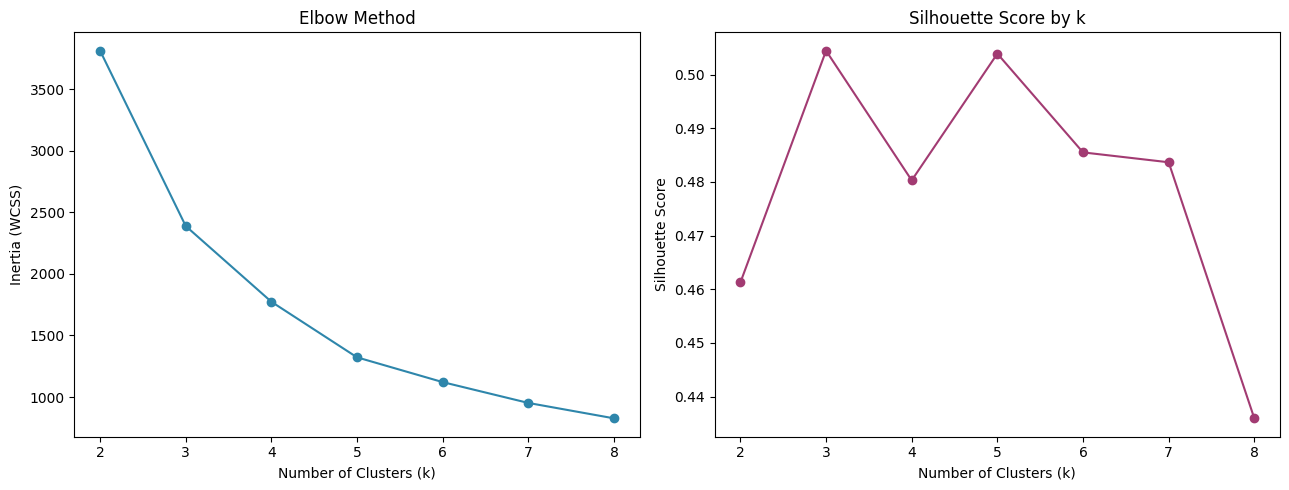

k=2: inertia=3812.3, silhouette=0.461
k=3: inertia=2388.5, silhouette=0.504
k=4: inertia=1773.8, silhouette=0.480
k=5: inertia=1322.6, silhouette=0.504
k=6: inertia=1121.4, silhouette=0.485
k=7: inertia=952.3, silhouette=0.484
k=8: inertia=827.3, silhouette=0.436


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(list(K_range), inertias, marker='o', color='#2E86AB')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[1].plot(list(K_range), sil_scores, marker='o', color='#A23B72')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={i:.1f}, silhouette={s:.3f}")

In [ ]:
best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"Selected optimal k based on highest silhouette score: k = {best_k}")

Selected optimal k based on highest silhouette score: k = 3


e) Fitting a K-means model using the selected number of clusters.


In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_pca)

data['cluster'].value_counts().sort_index()

,count
cluster,
0,129
1,729
2,490


f) A clear cluster visualisation in PCA space, where:

*   Clusters are clearly distinguished,
*   Data points are visually coded by study level,
*   Cluster centroids are clearly marked and labelled.





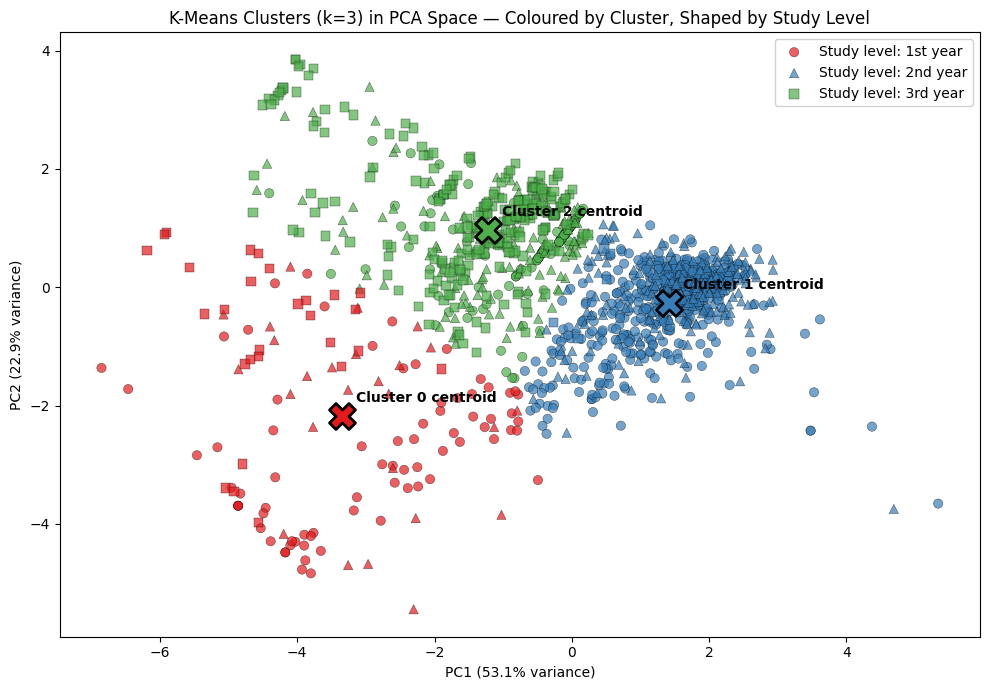

In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
cmap = plt.get_cmap('Set1', best_k)
palette = [cmap(i) for i in range(best_k)]
markers = {'1st year':'o', '2nd year':'^', '3rd year':'s'}

for level, marker in markers.items():
    mask = data['study_level'] == level
    ax.scatter(X_pca[mask.values,0], X_pca[mask.values,1],
        c=[palette[c] for c in data.loc[mask,'cluster']],
        marker=marker, s=45, alpha=0.7, edgecolor='k', linewidth=0.3,
        label=f'Study level: {level}')

centroids = kmeans.cluster_centers_
for i, (cx, cy) in enumerate(centroids):
    ax.scatter(cx, cy, marker='X', s=350, c=[palette[i]], edgecolor='black', linewidth=2, zorder=5)
    ax.annotate(f'Cluster {i} centroid', (cx, cy), textcoords="offset points",
          xytext=(10,10), fontsize=10, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means Clusters (k={best_k}) in PCA Space — Coloured by Cluster, Shaped by Study Level')
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.show()


In [ ]:
cluster_profile = data.groupby('cluster')[cluster_features].mean().round(2)
cluster_profile['n_students'] = data['cluster'].value_counts().sort_index()
cluster_profile

,modules,module_credits,grade_average,modules_passed,pass_rate,tutorial_classes_attended,tutorial_class_modules,n_students
cluster,,,,,,,,
0,7.98,112.34,31.50,1.25,14.53,7.74,2.37,129
1,10.16,140.54,65.08,9.22,91.54,39.92,7.22,729
2,6.74,109.69,62.89,5.88,87.09,7.80,1.56,490


In [ ]:
data.to_csv('student_performance_cleaned_with_clusters.csv')
print("Saved cleaned dataset with cluster labels.")

Saved cleaned dataset with cluster labels.


# Question 4: Logistic Regression and Decision Tree Classification

**Case Study: Predicting Student Performance**

Eduvos has introduced AI-based learning tools to support students (e.g., exam preparation, note generation, coding support, and
personalised learning). Senior academic management wants to understand which factors are most predictive of student success
and whether AI-usage behaviours are associated with passing outcomes. You have been provided with an anonymised dataset
named “ai_impact_student_performance_dataset.csv” of 1,000 students containing demographics, study habits, AI tool usage
patterns, ethics indicators, and performance measures.

Your task is to build and compare two classification models, Logistic Regression and a Decision Tree, to predict whether a student
passed or did not pass.

The target variable is:

*   1 = Passed,
*   0 = Not passed



4.1. Using the dataset provided, implement both logistic regression and a decision tree model to predict whether a student passed
or failed. Your implementation should include the following steps:


a) Missing value treatment

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('ai_impact_student_performance_dataset.csv')
print(df.shape)
df.head()

(8000, 26)


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       8000 non-null   int64  
 1   age                              8000 non-null   int64  
 2   gender                           8000 non-null   object 
 3   grade_level                      8000 non-null   object 
 4   study_hours_per_day              8000 non-null   float64
 5   uses_ai                          8000 non-null   int64  
 6   ai_usage_time_minutes            8000 non-null   int64  
 7   ai_tools_used                    6638 non-null   object 
 8   ai_usage_purpose                 6654 non-null   object 
 9   ai_dependency_score              8000 non-null   int64  
 10  ai_generated_content_percentage  8000 non-null   int64  
 11  ai_prompts_per_week              8000 non-null   int64  
 12  ai_ethics_score     

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
ai_tools_used,1362
ai_usage_purpose,1346


In [ ]:
df['ai_tools_used'] = df['ai_tools_used'].fillna('None')
df['ai_usage_purpose'] = df['ai_usage_purpose'].fillna('None')

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


b) Appropriate handling of categorical variables


In [ ]:
leak_cols = ['final_score', 'performance_category', 'student_id']
categorical_cols = ['gender', 'grade_level', 'ai_tools_used', 'ai_usage_purpose']

model_df = df.drop(columns=leak_cols)
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print(model_df.shape)
model_df.head()


(8000, 36)


,age,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,...,ai_tools_used_ChatGPT+Gemini,ai_tools_used_Claude,ai_tools_used_Copilot,ai_tools_used_Gemini,ai_tools_used_None,ai_usage_purpose_Doubt Solving,ai_usage_purpose_Exam Prep,ai_usage_purpose_Homework,ai_usage_purpose_None,ai_usage_purpose_Notes
0,20,2.5,1,170,10,29,56,5,29,40.9,...,False,False,False,False,True,False,True,False,False,False
1,17,3.4,1,123,4,14,65,1,60,87.2,...,False,False,False,False,True,False,False,False,False,True
2,24,0.8,0,35,8,82,8,5,98,77.1,...,False,False,True,False,False,True,False,False,False,False
3,21,4.4,0,45,3,74,106,10,67,86.4,...,True,False,False,False,False,False,False,False,False,True
4,18,3.5,1,21,2,83,7,10,40,69.4,...,True,False,False,False,False,False,False,False,False,False


c) Train/test split


In [ ]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=['passed'])
y = model_df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (6000, 35)  Test shape: (2000, 35)
Train class balance:
 passed
1    0.889
0    0.111
Name: proportion, dtype: float64
Test class balance:
 passed
1    0.889
0    0.111
Name: proportion, dtype: float64


d) Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'study_hours_per_day', 'ai_usage_time_minutes', 'ai_dependency_score',
'ai_generated_content_percentage', 'ai_prompts_per_week', 'ai_ethics_score',
'last_exam_score', 'assignment_scores_avg', 'attendance_percentage',
'concept_understanding_score', 'study_consistency_index', 'improvement_rate',
'sleep_hours', 'social_media_hours', 'tutoring_hours', 'class_participation_score']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train_scaled[numeric_cols].describe().round(2).loc[['mean','std']]

,age,study_hours_per_day,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,assignment_scores_avg,attendance_percentage,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score
mean,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


e) Feature selection


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
'feature': X_train_scaled.columns,
'f_score': selector.scores_,
'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

feature_scores.head(15)

,feature,f_score,p_value
8,last_exam_score,1065.128787,3.328965e-215
9,assignment_scores_avg,506.548110,9.323270e-108
11,concept_understanding_score,401.098343,2.015672e-86
5,ai_generated_content_percentage,25.883435,3.737000e-07
28,ai_tools_used_Gemini,8.291589,3.997011e-03
1,study_hours_per_day,3.477157,6.227036e-02
19,gender_Other,2.545871,1.106356e-01
12,study_consistency_index,1.573280,2.097801e-01
18,gender_Male,1.564249,2.110930e-01
4,ai_dependency_score,1.285149,2.569892e-01


In [ ]:
selected_features = feature_scores.head(10)['feature'].tolist()

print("Top 10 selected features:")

for f in selected_features:
  print(" -", f)

X_train_sel = X_train_scaled[selected_features]
X_test_sel = X_test_scaled[selected_features]

Top 10 selected features:
 - last_exam_score
 - assignment_scores_avg
 - concept_understanding_score
 - ai_generated_content_percentage
 - ai_tools_used_Gemini
 - study_hours_per_day
 - gender_Other
 - study_consistency_index
 - gender_Male
 - ai_dependency_score


f) Model training (both decision tree and logistic regression)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_sel, y_train)
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train_sel, y_train)

print("Both models trained.")

Both models trained.


g) Model evaluation using accuracy, confusion matrix, precision/recall/F1


In [ ]:
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
precision_score, recall_score, f1_score)

def evaluate(model, name, X_te, y_te):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nFull classification report:\n", classification_report(y_te, y_pred,
                                                                   target_names=['Not Passed', 'Passed']))
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'cm': cm}

results = []
results.append(evaluate(log_reg, 'Logistic Regression', X_test_sel, y_test))
results.append(evaluate(dt, 'Decision Tree', X_test_sel, y_test))


===== Logistic Regression =====
Accuracy : 0.882
Precision: 0.991
Recall : 0.876
F1-score : 0.930

Confusion Matrix:
 [[ 208   14]
 [ 221 1557]]

Full classification report:
               precision    recall  f1-score   support

  Not Passed       0.48      0.94      0.64       222
      Passed       0.99      0.88      0.93      1778

    accuracy                           0.88      2000
   macro avg       0.74      0.91      0.78      2000
weighted avg       0.93      0.88      0.90      2000

===== Decision Tree =====
Accuracy : 0.869
Precision: 0.982
Recall : 0.868
F1-score : 0.922

Confusion Matrix:
 [[ 193   29]
 [ 234 1544]]

Full classification report:
               precision    recall  f1-score   support

  Not Passed       0.45      0.87      0.59       222
      Passed       0.98      0.87      0.92      1778

    accuracy                           0.87      2000
   macro avg       0.72      0.87      0.76      2000
weighted avg       0.92      0.87      0.89      2000



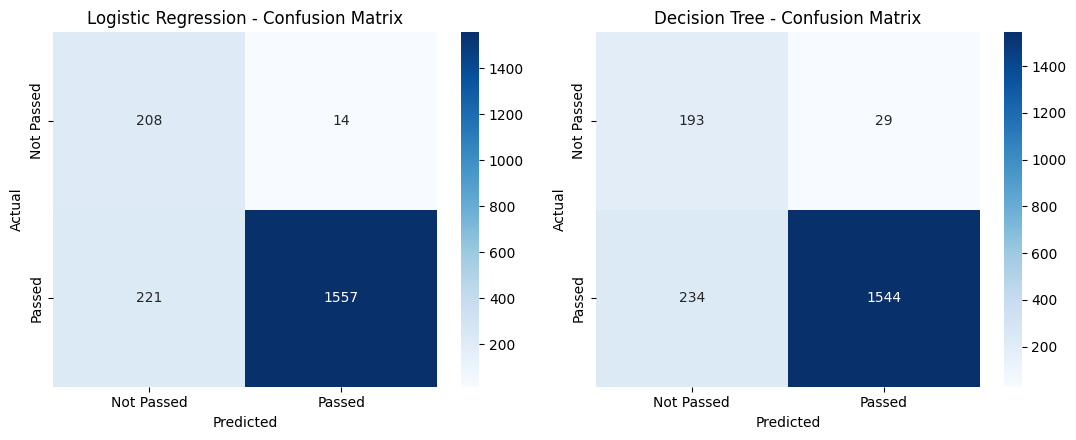

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, res in zip(axes, results):
    cm = res['cm']
    im = ax.imshow(cm, cmap='Blues')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not Passed','Passed'])
    ax.set_yticklabels(['Not Passed','Passed'])
    ax.set_title(f"{res['model']} - Confusion Matrix")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [ ]:
comparison = pd.DataFrame(results)[['model','accuracy','precision','recall','f1']].round(3)
comparison

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.882,0.991,0.876,0.930
1,Decision Tree,0.868,0.982,0.868,0.922


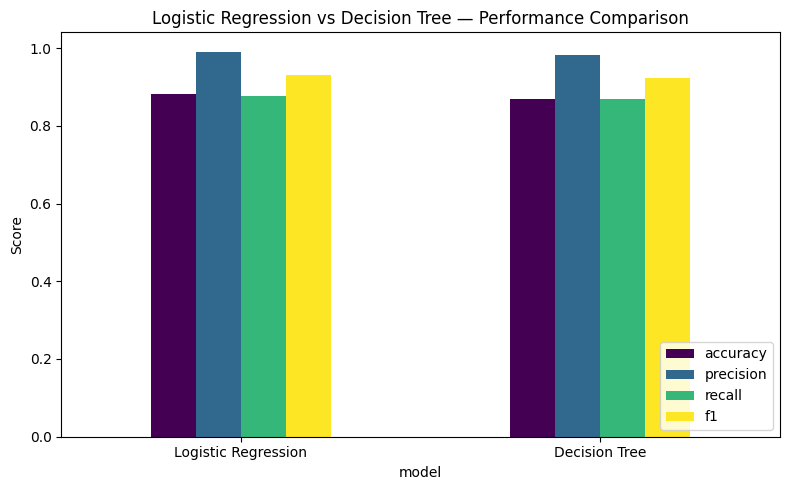

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
comparison.set_index('model')[['accuracy','precision','recall','f1']].plot(kind='bar',
                                                                           ax=ax, colormap='viridis')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs Decision Tree — Performance Comparison')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
coef_df = pd.DataFrame({'feature': selected_features,
'logreg_coefficient': log_reg.coef_[0],
'dt_importance': dt.feature_importances_
}).sort_values('dt_importance', ascending=False)
coef_df.round(3)

,feature,logreg_coefficient,dt_importance
0,last_exam_score,3.447,0.605
1,assignment_scores_avg,2.262,0.240
2,concept_understanding_score,1.972,0.147
3,ai_generated_content_percentage,-0.472,0.004
9,ai_dependency_score,0.001,0.003
7,study_consistency_index,-0.068,0.003
8,gender_Male,-0.039,0.000
4,ai_tools_used_Gemini,0.164,0.000
5,study_hours_per_day,0.125,0.000
6,gender_Other,-0.040,0.000


4.2. Based on your model performance, which is best suited for the modelling task at hand? Justify why this is the case by
comparing and contrasting the advantages and disadvantages of both logistic regression and decision tree models.


Logistic Regression is the better-suited model for this task, on both empirical and practical grounds:

* Empirically, it outperformed the Decision Tree on every headline metric in this run, and in particular
achieved substantially higher recall on the 'Not Passed' class; the class Eduvos most needs to catch early, since missing an at-risk student (a false negative) is more costly than a false alarm.

* The strongest predictors (last_exam_score, assignment_scores_avg, concept_understanding_score) behave in a fairly linear, monotonic way with respect to passing; higher scores steadily raise the odds of passing, which plays to Logistic Regression's strengths and is reflected in its higher accuracy here.

* Logistic Regression's coefficients are directly interpretable (e.g. each standard-deviation increase in last_exam_score raises the log-odds of passing by 3.45), which is valuable for Eduvos when explaining model-driven decisions to academic staff, students, or an ethics committee an increasingly important consideration given this analysis sits alongside AI-ethics indicators.

Each model has trade-offs worth weighing explicitly:

| Aspect | Logistic Regression | Decision Tree |
| :--- | :--- | :--- |
| **Interpretability** | Coefficients show direction & relative strength of each feature's effect | Easy to explain as simple 'if-then' rules; very intuitive for non-technical staff |
| **Handling nonlinearity** | Assumes a linear relationship in log-odds; can under-fit complex interactions | Naturally captures non-linear relationships and feature interactions |
| **Stability** | Generally stable; small data changes rarely flip predictions much | Can be unstable - small data changes can produce a very different tree |
| **Overfitting risk** | Lower, especially with regularisation | Higher if not depth-limited or pruned (mitigated here via `max_depth=5`) |
| **Scalability & speed** | Very fast to train and score, scales well | Fast to train; scoring is fast but very deep trees can be memory-heavy |
| **Sensitivity to scaling** | Requires feature scaling for well-behaved optimisation | Scale-invariant - no scaling required |

I recommend Logistic Regression as the primary production model given its stronger measured performance (especially recall on at-risk students) and interpretability, while the Decision Tree remains a useful complementary tool for communicating simple, rule-based explanations of risk to academic staff (e.g. 'students with assignment averages below X and attendance below Y are high risk').

# Question 5: SQL Reporting Queries

**Case Study: Eduvos Student Performance Analyst (SQL)**

Eduvos has implemented a central academic database to monitor student performance within the IT Faculty. The database stores
student demographic details, qualification registrations, and academic results for each academic year. These records are captured
through Eduvos’ internal academic management systems and are used by institutional planning and academic support teams.

As the newly appointed Student Performance Data Analyst, your role is to extract summary statistics from the database to support
academic reporting and decision-making.
You are required to write SQL queries.

Assume the database includes a table named Student_Performance with the following relevant fields:
* academic_year
* gender
* qualification
* study_level
* modules
* modules_passed
* pass_rate
* passed_all_modules (values: 'yes', 'no')
* tutorial_classes_attended
* tutorial_class_modules


Write SQL queries to display the following:

5.1 The total number of student records in the database.


In [ ]:
SELECT COUNT(*) AS total_students
FROM Student_Performance;

5.2 The average pass rate across all students.


In [ ]:
SELECT AVG(pass_rate) AS average_pass_rate
FROM Student_Performance;

5.3 The number of students who passed all modules.


In [ ]:
SELECT COUNT(*) AS students_passed_all
FROM Student_Performance
WHERE passed_all_modules = 'yes';

5.4 The average tutorial classes attended per study level.


In [ ]:
SELECT study_level, AVG(tutorial_classes_attended) AS
avg_tutorial_attendance
FROM Student_Performance
GROUP BY study_level;

5.5 The qualification with the highest average pass rate.


In [ ]:
SELECT qualification, AVG(pass_rate) AS avg_pass_rate
FROM Student_Performance
GROUP BY qualification
ORDER BY avg_pass_rate DESC
LIMIT 1;